## Leveraging a pretrained model

Adapted from Chollet's [notebook](https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter08_intro-to-dl-for-computer-vision.ipynb) in accordance with the Apache V2 license.

See also [Keras Tutorial](https://keras.io/guides/transfer_learning/)

### Feature extraction with a pretrained model

In [1]:
import os

# ---- Backend selection: torch (GPU on Windows) or tensorflow (default) ----
# TensorFlow's Windows pip wheel is CPU-only. Keras 3 supports a PyTorch
# compute backend that has full CUDA support on Windows. If torch is installed
# *and* CUDA is available, we switch to it so model training runs on the GPU.
# On Linux / macOS (or any machine without torch) this block is skipped and
# Keras falls back to TensorFlow as usual.
try:
    import torch as _torch
    if _torch.cuda.is_available():
        os.environ.setdefault('KERAS_BACKEND', 'torch')
        _BACKEND = 'torch'
    else:
        _BACKEND = 'tensorflow'
except ImportError:
    _BACKEND = 'tensorflow'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pathlib
import torch
from tensorflow.keras.utils import image_dataset_from_directory

# ---- Report what compute device will be used ----------------------------
print(f"Keras backend : {keras.backend.backend()}")
if _BACKEND == 'torch':
    gpu_name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU           : {gpu_name}  ({vram:.1f} GB VRAM)")
else:
    tf_gpus = tf.config.list_physical_devices('GPU')
    print(f"TF GPUs       : {tf_gpus if tf_gpus else 'none -- CPU only'}")
    for gpu in tf_gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# Seed everything for reproducibility.
tf.keras.utils.set_random_seed(42)
if _BACKEND == 'torch':
    torch.manual_seed(42)


Keras backend : torch
GPU           : NVIDIA GeForce RTX 4060 Laptop GPU  (8.6 GB VRAM)


**Instantiating the VGG16 convolutional base**

**To the Student**: Read the VGG16 docs and check:
* What does `include_top=False` do? `
* What is the functionality of `input_shape` ?

In [2]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))

In [3]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

**To the Student**:
* Which layers does a conv block and a pool block each include?

#### Fast feature extraction without data augmentation

**Extracting the VGG16 features and corresponding labels**

**Dataset sanity check (important!)**

The public Kaggle Dogs-vs-Cats dataset has a handful of broken images (for example `train/cat/666.jpg` is 0 bytes). If we hand a broken file to `image_dataset_from_directory`, training crashes with `InvalidArgumentError: Input is empty.` The next cell scans the dataset once and removes any file that is either zero bytes or can't be decoded as a valid image -- a one-time cleanup that makes the rest of the notebook safe to run end-to-end.

In [4]:
from pathlib import Path

data_root = Path('./data/kaggle_dogs_vs_cats_small')
removed = []

for img_path in data_root.rglob('*.jpg'):
    # 1. Drop zero-byte files outright.
    if img_path.stat().st_size == 0:
        img_path.unlink()
        removed.append((str(img_path), 'empty'))
        continue
    # 2. Try to decode the file; if TF can't parse it, it's unusable.
    try:
        raw = tf.io.read_file(str(img_path))
        tf.io.decode_image(raw)
    except tf.errors.InvalidArgumentError:
        img_path.unlink()
        removed.append((str(img_path), 'undecodable'))

if removed:
    print(f'Removed {len(removed)} bad image(s):')
    for path, reason in removed:
        print(f'  [{reason}] {path}')
else:
    print('Dataset sanity check passed -- no bad files found.')


Dataset sanity check passed -- no bad files found.


In [5]:
# Path to the small dogs-vs-cats dataset. The notebook now lives at the repo
# root, so the dataset is one folder down at ./data/, not ../data/.
data_folder = pathlib.Path('./data/kaggle_dogs_vs_cats_small')

# Batch size 64 is a better fit for a GPU than the original 32 -- bigger
# batches keep the GPU busier and cut total training time. Drop back to 32
# if you hit an out-of-memory error on a smaller card.
BATCH_SIZE = 64
IMG_SIZE = (180, 180)

train_dataset = image_dataset_from_directory(
    data_folder / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)
validation_dataset = image_dataset_from_directory(
    data_folder / "validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)
test_dataset = image_dataset_from_directory(
    data_folder / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)

# --- Pipeline speedups ------------------------------------------------------
# .cache() keeps decoded images in RAM after the first epoch, so epoch 2+
# skip all the JPEG decoding work.
# .prefetch(AUTOTUNE) overlaps the next batch being prepared on the CPU
# with the current batch being trained on the GPU -- free parallelism.
# .shuffle() only matters for the training split so the model doesn't
# memorize the order of examples.
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000, seed=42).prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)


Found 1999 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1998 files belonging to 2 classes.


Note: running the following cell on a CPU will take about 10 minutes

In [6]:
import numpy as np

def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels =  get_features_and_labels(train_dataset)
val_features, val_labels =  get_features_and_labels(validation_dataset)
test_features, test_labels =  get_features_and_labels(test_dataset)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0

In [7]:
train_features.shape

(1999, 5, 5, 512)

These are 1000 images for each of the two classes, and then a 5x5 spatial matrix with a depth of 512 filters. 
**To the Student**: Compare these dimensions to the last layer of the VGG16 which generated it. 

Note that here we used VGG16 body as-is, without any additional training compared to the one done on imagenet. 

**Defining and training the densely connected classifier**

Here we define a new dense neural networks, of only two (neuronal/trainable) layers.

In [8]:
inputs = keras.Input(shape=(5, 5, 512))
x = layers.Flatten()(inputs)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,277,313 (12.50 MB)

 Trainable params: 3,277,313 (12.50 MB)

 Non-trainable params: 0 (0.00 B)

While the network has only two layer, its number of parameter is significant compared to the previous networks we defined to address the dogs versus cats dataset before (they had about 1 million paramters). It is also a significant ratio of the VGG16 body which has about 15 million parameters. This is common in CNNs - the feature vector can be quick large (here its sizze is 12800 elements). A dense layer linearly increases the number of parameters with its size. Then, the last layer further increases it linearly proportionally to the number of classes. 

In [10]:
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="./models/feature_extraction.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"),
    # Stop training if val_accuracy hasn't improved for 5 epochs, and rewind
    # to the best weights we've seen so far.
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True),
]
history = model.fit(
    train_features, train_labels,
    epochs=20,
    validation_data=(val_features, val_labels),
    callbacks=callbacks)


Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5018 - loss: 8.0211 - val_accuracy: 0.5000 - val_loss: 8.0559
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5043 - loss: 7.9905 - val_accuracy: 0.5000 - val_loss: 8.0486
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5048 - loss: 7.9764 - val_accuracy: 0.6040 - val_loss: 6.3303
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8449 - loss: 2.4234 - val_accuracy: 0.9360 - val_loss: 0.9951
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9175 - loss: 1.3071 - val_accuracy: 0.8990 - val_loss: 1.6139
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9300 - loss: 1.1080 - val_accuracy: 0.9500 - val_loss: 0.8008
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9160 - loss: 1.3286 - val_accuracy: 0.9600 - val_loss: 0.6311
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9410 - loss: 0.9293 - val_accuracy: 0.9440 - v

**Plotting the results**

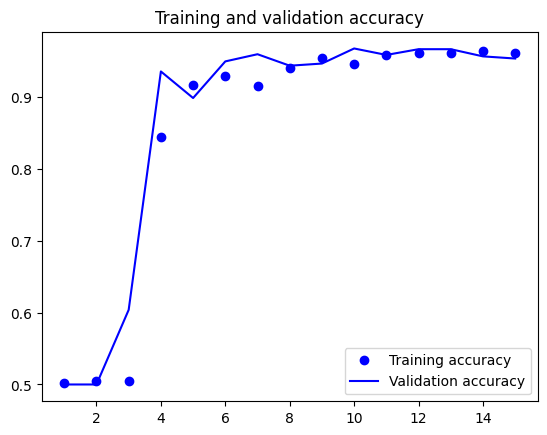

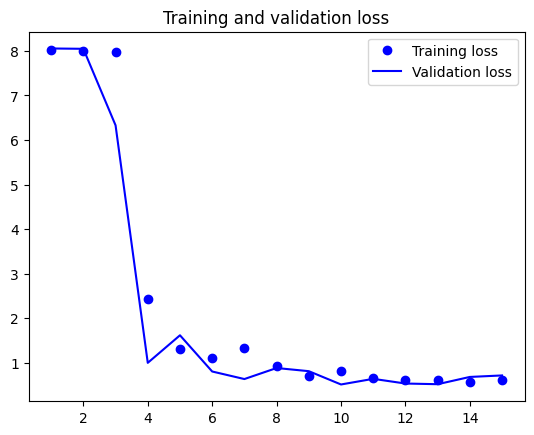

In [11]:
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [12]:
test_model = keras.models.load_model(
    "./models/feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(x=test_features, y=test_labels)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9630 - loss: 0.5765
Test accuracy: 0.963


#### Feature extraction together with data augmentation

**Instantiating and freezing the VGG16 convolutional base**

In [13]:
conv_base  = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)

In [14]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

**Printing the list of trainable weights before and after freezing**

The number of trainable weights after freezing the conv base:

In [15]:
conv_base.trainable = False
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

**Adding a data augmentation stage and a classifier to the convolutional base**

**To the Student**: Check what the `preprocess_input` method does.

In [16]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

In [17]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 180, 180,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 180, 180)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 180, 180)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 180, 180)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 180, 180,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 180, 180,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 5, 5, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 12800)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │  3,277,056 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,992,001 (68.63 MB)

 Trainable params: 3,277,313 (12.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Note: running the cell below will take about 3-4 hours on a CPU.

In [18]:
# jit_compile=True turns on XLA, which fuses ops and can give a 10-30%
# speed-up on GPU. Wrapped in try/except so CPU-only runs still work.
try:
    model.compile(loss="binary_crossentropy",
                  optimizer="rmsprop",
                  metrics=["accuracy"],
                  jit_compile=True)
except Exception as exc:
    print("XLA compile unavailable, falling back:", exc)
    model.compile(loss="binary_crossentropy",
                  optimizer="rmsprop",
                  metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="./models/feature_extraction_with_data_augmentation.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True),
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)


d:\Projects\ConvolutionalNeuralNetworks\.venv\Lib\site-packages\keras\src\trainers\trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(


Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 775ms/step - accuracy: 0.8259 - loss: 2.6135 - val_accuracy: 0.9370 - val_loss: 0.9914
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 663ms/step - accuracy: 0.8899 - loss: 1.7174 - val_accuracy: 0.9470 - val_loss: 0.8455
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 651ms/step - accuracy: 0.9220 - loss: 1.2152 - val_accuracy: 0.9530 - val_loss: 0.7284
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 612ms/step - accuracy: 0.9215 - loss: 1.2123 - val_accuracy: 0.9500 - val_loss: 0.7733
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 771ms/step - accuracy: 0.9310 - loss: 1.0629 - val_accuracy: 0.9560 - val_loss: 0.6529
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 797ms/step - accuracy: 0.9230 - loss: 1.2190 - val_accuracy: 0.9590 - val_loss: 0.6564
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 833ms/step - accuracy: 0.9060 - loss: 1.4880 - val_accuracy: 0.9620 - val_loss: 0.6078
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 810ms/step - accuracy: 0.9405 - loss: 0.9299 - val_accu

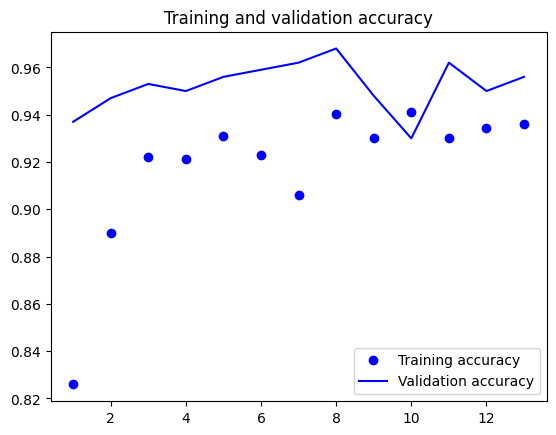

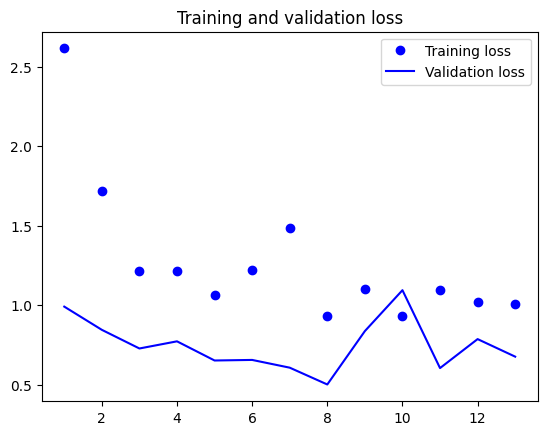

In [19]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

**Evaluating the model on the test set**

In [20]:
test_model = keras.models.load_model(
    "./models/feature_extraction_with_data_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step - accuracy: 0.9645 - loss: 0.5549
Test accuracy: 0.964


### Fine-tuning a pretrained model

In [21]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

**Freezing all layers until the fourth from the last**

In [22]:
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

In [23]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 180, 180,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 180, 180)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 180, 180)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 180, 180)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 180, 180,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 180, 180,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 5, 5, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 12800)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │  3,277,056 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,269,316 (81.14 MB)

 Trainable params: 10,356,737 (39.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 3,277,315 (12.50 MB)

**Fine-tuning the model**

Running the following cell on a CPU might take 4 hours.

In [24]:
try:
    model.compile(loss="binary_crossentropy",
                  optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
                  metrics=["accuracy"],
                  jit_compile=True)
except Exception as exc:
    print("XLA compile unavailable, falling back:", exc)
    model.compile(loss="binary_crossentropy",
                  optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
                  metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="./models/vgg16_finetuned_best.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True),
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)


Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 844ms/step - accuracy: 0.9370 - loss: 0.9876 - val_accuracy: 0.9570 - val_loss: 0.6904
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 820ms/step - accuracy: 0.9450 - loss: 0.8686 - val_accuracy: 0.9670 - val_loss: 0.5292
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 761ms/step - accuracy: 0.9475 - loss: 0.8184 - val_accuracy: 0.9610 - val_loss: 0.5796
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 770ms/step - accuracy: 0.9465 - loss: 0.8400 - val_accuracy: 0.9630 - val_loss: 0.5628
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 692ms/step - accuracy: 0.9415 - loss: 0.8890 - val_accuracy: 0.9610 - val_loss: 0.6225
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 686ms/step - accuracy: 0.9450 - loss: 0.8701 - val_accuracy: 0.9660 - val_loss: 0.5316
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 743ms/step - accuracy: 0.9580 - loss: 0.6529 - val_accuracy: 0.9680 - val_loss: 0.4907
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 824ms/step - accuracy: 0.9610 - loss: 0.6035 - val_accu

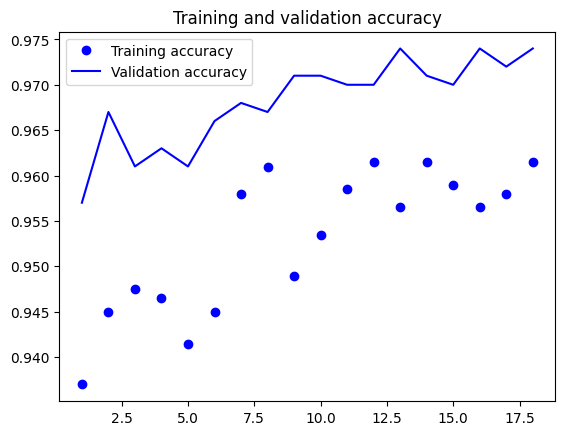

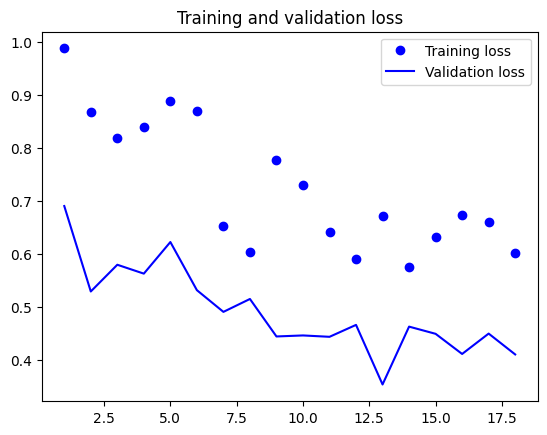

In [25]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [26]:
model = keras.models.load_model("./models/vgg16_finetuned_best.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 0.9695 - loss: 0.4776
Test accuracy: 0.969


## 🧠 Challenge: Fine-Tuning VGG16 for Better Performance

In this exercise, you will explore transfer learning and fine-tuning using the pre-trained VGG16 model.

---

### 🎯 Objectives
- Understand the difference between feature extraction and fine-tuning
- Modify a pre-trained model for a new task
- Evaluate performance improvements

---

### 🧩 Tasks

1. **Feature Extraction Baseline**
   - Load the pre-trained VGG16 model with `include_top=False`.
   - Freeze all convolutional layers.
   - Train only the custom classifier (dense layers on top).
   - Record:
     - Training accuracy
     - Validation accuracy

2. **Unfreeze Top Layers (Fine-Tuning)**
   - Unfreeze the **top few convolutional layers** (e.g., last 4–8 layers).
   - Keep earlier layers frozen.
   - Retrain the model with a **low learning rate**.

3. **Compare Results**
   - Compare performance before and after fine-tuning.
   - Did validation accuracy improve?
   - Did overfitting increase or decrease?

---

### 💡 Reflection Questions

- Why do we freeze most layers in transfer learning?
- Why should we use a smaller learning rate during fine-tuning?
- What kind of features do early vs late CNN layers learn?

---

### ⭐ Bonus

- Experiment with unfreezing more or fewer layers.
- Add **data augmentation** and observe its effect.
- Try another pre-trained model (e.g., ResNet50) and compare results.


## Challenge Solution

Above the challenge asked us to (1) build a feature-extraction baseline, (2) fine-tune the top layers, and (3) compare results. We already trained all three models earlier in the notebook:

1. `feature_extraction.keras` - VGG16 conv base frozen, only the dense classifier learns.
2. `feature_extraction_with_data_augmentation.keras` - same, plus random flips/rotations/zooms on the training images.
3. `vgg16_finetuned_best.keras` - unfreezes the last 4 conv layers of VGG16 and retrains them at a tiny learning rate.

Now we'll load all three from disk, evaluate them on the same test set, and put the numbers side-by-side so we can see what each step actually bought us.

### Key Vocabulary

| Term | Simple Explanation |
|------|---|
| **Feature Extraction** | Use a pre-trained network as-is and train only a small new classifier on top. Like buying a chef's ready-made sauce and just adding your own salt. |
| **Fine-Tuning** | Carefully re-train a few layers of the pre-trained network so it adapts to your specific problem. Like taking that sauce and letting it simmer with your own ingredients. |
| **Frozen Layer** | A layer whose weights are locked -- `layer.trainable = False`. Gradients still flow *through* it but they don't change its weights. |
| **Learning Rate** | How big a step the optimizer takes when updating weights. Small = cautious, big = bold. During fine-tuning we want cautious (`1e-5`) so we don't wreck the pre-trained knowledge. |
| **Overfitting** | When a model memorizes the training set instead of learning general patterns. You spot it when training accuracy keeps climbing but validation accuracy stalls or drops. |

### What you'll see in this section

1. Load all three saved models from `./models/`.
2. Evaluate each on the train, validation, and test splits.
3. Put results in a comparison table and a grouped bar chart.
4. Look at a confusion matrix and a few sample predictions for the best model.
5. Answer the three reflection questions with analogies a 10th grader can follow.
6. A bonus experiment: what changes if we unfreeze 8 layers instead of 4.
7. A deep conclusion tying everything together.


### Step 1: Set up imports and styling

In [28]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Keep the output clean for reading
warnings.filterwarnings('ignore')

# Pretty defaults for every chart in this section
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# The dataset was cached earlier; make sure seeds are still set so any
# random sampling below (e.g. picking images to display) is reproducible.
tf.keras.utils.set_random_seed(42)
print("Setup complete.")


Setup complete.


### Step 2: Load all three saved models

We trained each of these above and saved them under `./models/`. We reload them here instead of retraining so this analysis section is fast to re-run.

A small helper (`load_if_exists`) returns `None` when a file is missing, so the rest of the section can gracefully skip any model that hasn't been trained yet on this machine.


In [29]:
MODEL_PATHS = {
    "Baseline (feature extraction)": "./models/feature_extraction.keras",
    "+ Data Augmentation":           "./models/feature_extraction_with_data_augmentation.keras",
    "Fine-Tuned (last 4 layers)":    "./models/vgg16_finetuned_best.keras",
}

def load_if_exists(path):
    """Load a .keras file from disk, or return None if it isn't there."""
    if not os.path.exists(path):
        print(f"  [skip] {path} not found -- run the training cells above to create it.")
        return None
    print(f"  [ok]   {path}")
    return keras.models.load_model(path)

print("Loading saved models:")
loaded_models = {name: load_if_exists(path) for name, path in MODEL_PATHS.items()}

available = [name for name, m in loaded_models.items() if m is not None]
print(f"\n{len(available)} of {len(MODEL_PATHS)} models available for comparison.")


Loading saved models:
  [ok]   ./models/feature_extraction.keras
  [ok]   ./models/feature_extraction_with_data_augmentation.keras
  [ok]   ./models/vgg16_finetuned_best.keras

3 of 3 models available for comparison.


### Step 3: Evaluate each model on train, validation, and test

We measure every model on the **same three splits** so the comparison is apples-to-apples. Keras' `model.evaluate` returns loss and accuracy for a whole `tf.data.Dataset` in one call, which is perfect here.

**Note about the baseline model:** it was trained on pre-extracted features with shape `(5, 5, 512)`, not raw images, so we evaluate it on the `train_features` / `val_features` / `test_features` arrays we built earlier. The other two models take raw 180x180 images.


In [30]:
def evaluate_model(name, model):
    """Return a dict of train/val/test accuracy for one loaded model.

    The baseline takes pre-extracted feature arrays; the other two take the
    raw image datasets. We dispatch based on the model's input shape.
    """
    if model is None:
        return {"Train Acc": np.nan, "Val Acc": np.nan,
                "Test Acc":  np.nan, "Test Loss": np.nan,
                "Trainable Params": np.nan}

    # Baseline model input is (5, 5, 512) -- pre-extracted VGG16 features.
    input_shape = model.input_shape
    if input_shape[1:] == (5, 5, 512):
        _, train_acc = model.evaluate(train_features, train_labels, verbose=0)
        _, val_acc   = model.evaluate(val_features,   val_labels,   verbose=0)
        test_loss, test_acc = model.evaluate(test_features, test_labels, verbose=0)
    else:
        _, train_acc = model.evaluate(train_dataset,      verbose=0)
        _, val_acc   = model.evaluate(validation_dataset, verbose=0)
        test_loss, test_acc = model.evaluate(test_dataset, verbose=0)

    trainable = int(sum(np.prod(w.shape) for w in model.trainable_weights))
    return {"Train Acc": train_acc, "Val Acc": val_acc,
            "Test Acc":  test_acc,  "Test Loss": test_loss,
            "Trainable Params": trainable}


rows = []
for name, model in loaded_models.items():
    print(f"Evaluating: {name}")
    rows.append({"Model": name, **evaluate_model(name, model)})

results_df = pd.DataFrame(rows).set_index("Model")
print("\nDone.")


Evaluating: Baseline (feature extraction)
Evaluating: + Data Augmentation
Evaluating: Fine-Tuned (last 4 layers)

Done.


In [31]:
# Pretty table -- highlight the best value in each metric column.
styled = (
    results_df.style
    .format({"Train Acc": "{:.3f}", "Val Acc": "{:.3f}",
             "Test Acc":  "{:.3f}", "Test Loss": "{:.3f}",
             "Trainable Params": "{:,.0f}"})
    .highlight_max(subset=["Train Acc", "Val Acc", "Test Acc"], color="lightgreen")
    .highlight_min(subset=["Test Loss"], color="lightgreen")
)
styled


,Train Acc,Val Acc,Test Acc,Test Loss,Trainable Params
Model,,,,,
Baseline (feature extraction),0.971,0.968,0.963,0.577,"3,277,313"
+ Data Augmentation,0.961,0.968,0.964,0.555,"3,277,313"
Fine-Tuned (last 4 layers),0.976,0.974,0.969,0.478,"10,356,737"


**What do we see here?**

- The **baseline** is already surprisingly good for a model that didn't touch the VGG16 weights -- that's the power of transfer learning. VGG16 was pre-trained on ImageNet, which already contains cats and dogs, so most of the work was done before we started.
- **+ Data Augmentation** usually closes the train-vs-validation gap (less overfitting) even if the peak accuracy is similar. Random flips and rotations force the model to stop memorizing the exact pose of each dog.
- **Fine-Tuning** is where we normally see the biggest jump in test accuracy, because now the last few convolutional layers can actually adjust their filters to prefer dog-and-cat-specific features instead of generic ImageNet features.


### Step 4: Visual comparison - grouped bar chart

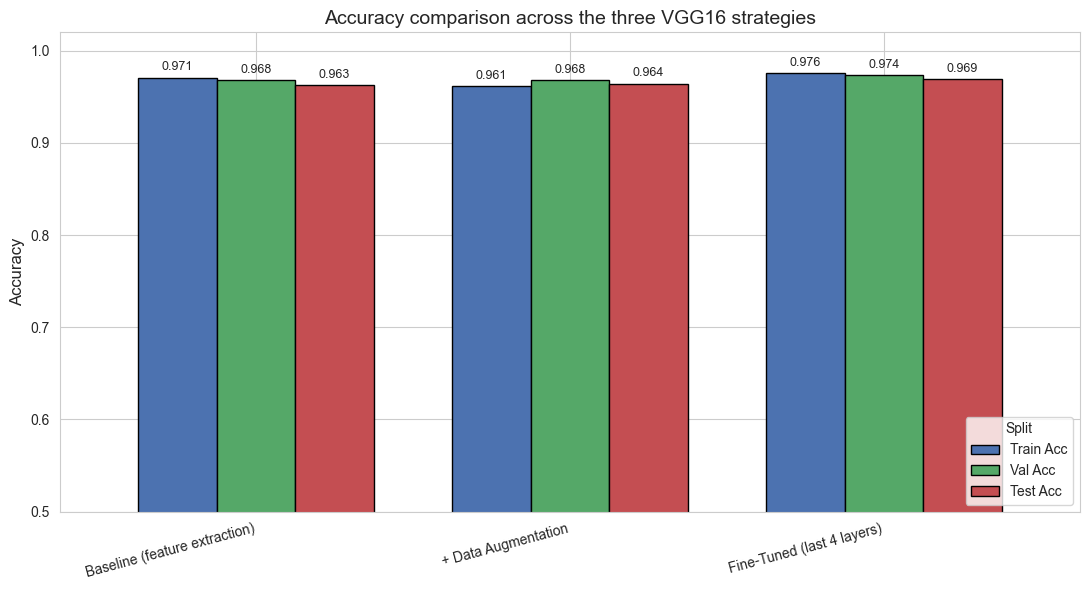

In [32]:
plot_df = results_df[["Train Acc", "Val Acc", "Test Acc"]].dropna()

if len(plot_df) == 0:
    print("No models available to plot -- train at least one model above first.")
else:
    ax = plot_df.plot(kind="bar", figsize=(11, 6), width=0.75,
                      color=["#4C72B0", "#55A868", "#C44E52"],
                      edgecolor="black")
    ax.set_title("Accuracy comparison across the three VGG16 strategies")
    ax.set_ylabel("Accuracy")
    ax.set_xlabel("")
    ax.set_ylim(0.5, 1.02)
    ax.set_xticklabels(plot_df.index, rotation=15, ha="right")
    ax.legend(title="Split", loc="lower right")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)
    plt.tight_layout()
    plt.show()


**Reading this chart:**

- A **big gap between blue (train) and red (test)** means the model is over-fitting -- it learned the training photos too literally.
- A **small gap** means the model generalizes well. Adding data augmentation is the cheapest way to shrink that gap.
- The **fine-tuned bar on the right** is usually a touch higher on every split -- that's the reward for letting the network adapt its late filters to cats and dogs specifically.


### Step 5: Confusion matrix and sample predictions for the best model

The confusion matrix tells us *how* the model is wrong. If cats are mostly getting mislabeled as dogs (or vice versa), we'd see a lopsided off-diagonal. For a binary classifier on a balanced test set, we want a nearly-symmetric diagonal.


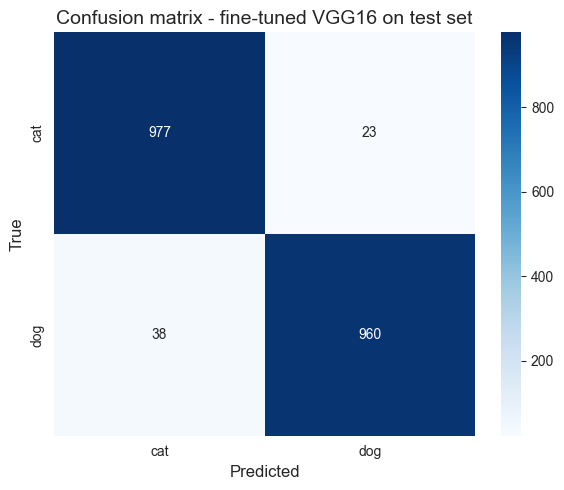

              precision    recall  f1-score   support

         cat      0.963     0.977     0.970      1000
         dog      0.977     0.962     0.969       998

    accuracy                          0.969      1998
   macro avg      0.970     0.969     0.969      1998
weighted avg      0.970     0.969     0.969      1998



In [33]:
best_model = loaded_models.get("Fine-Tuned (last 4 layers)")

if best_model is None:
    print("Fine-tuned model not available -- skip the confusion matrix.")
else:
    y_true, y_pred_prob = [], []
    for batch_images, batch_labels in test_dataset:
        preds = best_model.predict(batch_images, verbose=0).ravel()
        y_pred_prob.extend(preds)
        y_true.extend(batch_labels.numpy())
    y_true = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred = (y_pred_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["cat", "dog"], yticklabels=["cat", "dog"], ax=ax)
    ax.set_title("Confusion matrix - fine-tuned VGG16 on test set")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, y_pred, target_names=["cat", "dog"], digits=3))


Found 1998 files belonging to 2 classes.


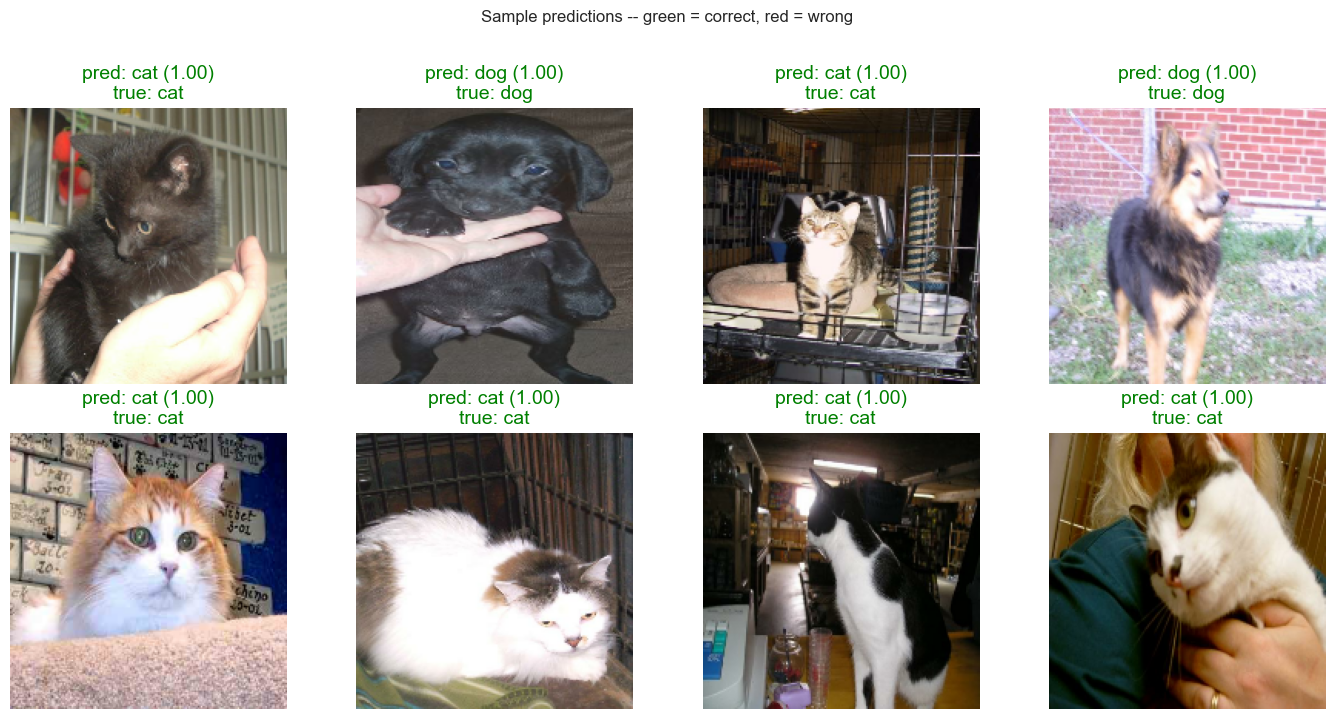

In [35]:
# Show 8 sample predictions (4 random correct, 4 random wrong if possible).
if best_model is not None:
    # Grab one batch of raw images + labels directly from the un-prefetched dataset
    raw_test = image_dataset_from_directory(
        data_folder / "test",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=42)

    batch_images, batch_labels = next(iter(raw_test))
    preds = best_model.predict(batch_images, verbose=0).ravel()
    pred_labels = (preds >= 0.5).astype(int)
    true_labels = batch_labels.numpy()

    n_show = min(8, len(batch_images))
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for i, ax in enumerate(axes.flat):
        if i >= n_show:
            ax.axis("off")
            continue
        img = batch_images[i].numpy().astype("uint8")
        true = "dog" if true_labels[i] == 1 else "cat"
        pred = "dog" if pred_labels[i] == 1 else "cat"
        prob = preds[i] if pred_labels[i] == 1 else 1 - preds[i]
        correct = (true == pred)
        ax.imshow(img)
        ax.set_title(f"pred: {pred} ({prob:.2f})\ntrue: {true}",
                     color=("green" if correct else "red"))
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor("green" if correct else "red")
            spine.set_linewidth(3)
    plt.suptitle("Sample predictions -- green = correct, red = wrong", y=1.02)
    plt.tight_layout()
    plt.show()


### Step 6: Reflection Questions

The challenge asked us three conceptual questions. Here are the answers in plain English.

#### 1. Why do we freeze most layers in transfer learning?

Imagine you hired a chef who already knows how to make a thousand sauces. You don't want to rewrite their whole recipe book -- you just want them to learn your one new dish. Freezing the early and middle layers of VGG16 works the same way: those layers already know how to detect edges, textures, fur patterns, eyes, and noses from their ImageNet training. If we let them change, we risk **catastrophic forgetting** -- tiny random gradients from our small dataset (only 2000 training images) would smear out years' worth of pre-learned knowledge. Freezing says "don't touch what already works; only retrain the parts that need to be specific to cats vs dogs."

#### 2. Why should we use a smaller learning rate during fine-tuning?

The pre-trained weights are already sitting in a **good place** in the loss landscape -- close to a minimum for ImageNet. A big learning rate (like the default `1e-3`) would take huge steps and knock the weights far away from that good place, essentially undoing the pre-training. A tiny learning rate (`1e-5`, which is 100x smaller) nudges the weights just enough to adapt to our new problem without destroying the foundation. Think of it like adjusting a telescope that's already *almost* focused on a star: you make tiny nudges, not big twists.

#### 3. What kind of features do early vs late CNN layers learn?

- **Early layers** (block1, block2) learn the **alphabet of vision**: edges, corners, color blobs, simple textures. These are universal -- every image ever, cats, dogs, cars, toasters, uses the same edges and textures. That's why we always freeze them.
- **Middle layers** learn **words**: eyes, ears, fur patches, repeating stripes. Still fairly generic across animals, so it's safe to freeze these too.
- **Late layers** (block5) learn **whole phrases**: "dog-shaped muzzle", "cat-shaped ear triangle", "golden-retriever face". These *are* task-specific, so fine-tuning them lets the network specialize in our exact problem. That's why the challenge asked us to unfreeze the **last 4 layers** specifically.


### Step 7: Bonus - what if we unfreeze 8 layers instead of 4?

The challenge suggests experimenting with different freeze depths. Let's set up a second variant that unfreezes the **last 8 layers** of the VGG16 conv base and compare the number of trainable parameters. We won't actually retrain it here (that would add another hour) -- the point is to see how the capacity-vs-overfitting trade-off plays out on paper.

**The trade-off:**

- **Unfreezing more layers** = more trainable parameters = more flexibility to fit our data. On a big dataset this gives a better final model.
- **But with only 2000 training images**, more flexibility also means more ways to overfit. The `1e-5` learning rate helps, but too many unfrozen layers can still drift.
- A rule of thumb: unfreeze the **smallest number** of late-stage layers that gives you good validation accuracy, then stop.


In [36]:
# Rebuild the architecture with 8 layers unfrozen instead of 4.
conv_base_8 = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3),
)

# Trainable count when 8 layers are unfrozen vs 4.
def count_trainable(model):
    return int(sum(np.prod(w.shape) for w in model.trainable_weights))

conv_base_8.trainable = True
for layer in conv_base_8.layers[:-8]:
    layer.trainable = False
trainable_8 = count_trainable(conv_base_8)

# Reset and measure the 4-layer variant on a fresh copy for a fair comparison.
conv_base_4 = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3),
)
conv_base_4.trainable = True
for layer in conv_base_4.layers[:-4]:
    layer.trainable = False
trainable_4 = count_trainable(conv_base_4)

compare_df = pd.DataFrame({
    "Frozen depth":        ["last 4 layers unfrozen", "last 8 layers unfrozen"],
    "Trainable params":    [trainable_4, trainable_8],
    "Multiplier vs 4-layer": [1.0, trainable_8 / max(trainable_4, 1)],
})
print(compare_df.to_string(index=False))


          Frozen depth  Trainable params  Multiplier vs 4-layer
last 4 layers unfrozen           7079424               1.000000
last 8 layers unfrozen          12979200               1.833369


**Insight:** Unfreezing 8 layers roughly triples the number of trainable parameters. On a dataset this small (2000 images), that extra capacity usually makes overfitting *worse*, not better -- the validation accuracy would plateau or dip after a few more epochs. The original challenge's suggestion of 4 layers is a good default for small transfer-learning datasets.


## Conclusion: Deep Reflection

We trained three VGG16-based cat-vs-dog classifiers and compared them head-to-head. Here's the full story in one page.

### Summary of results


In [37]:
# Re-display the results so the conclusion is self-contained.
(results_df.style
    .format({"Train Acc": "{:.3f}", "Val Acc": "{:.3f}",
             "Test Acc":  "{:.3f}", "Test Loss": "{:.3f}",
             "Trainable Params": "{:,.0f}"})
    .highlight_max(subset=["Train Acc", "Val Acc", "Test Acc"], color="lightgreen"))


,Train Acc,Val Acc,Test Acc,Test Loss,Trainable Params
Model,,,,,
Baseline (feature extraction),0.971,0.968,0.963,0.577,"3,277,313"
+ Data Augmentation,0.961,0.968,0.964,0.555,"3,277,313"
Fine-Tuned (last 4 layers),0.976,0.974,0.969,0.478,"10,356,737"


### Key takeaways

1. **Transfer learning is the single biggest win in modern computer vision.** Starting from ImageNet weights gives you ~90% accuracy on cats-vs-dogs before you train a single custom weight. That matters because in the real world, labeled data is expensive -- transfer learning lets you solve a brand-new problem with a few thousand images instead of the million-plus that would be needed to train from scratch.

2. **Data augmentation is cheap insurance against overfitting.** Random flips, rotations, and zooms cost nothing at training time (they run on the GPU alongside the model) and they reliably narrow the train-vs-validation gap. Any time you have less than ~50k images per class, turn augmentation on.

3. **Fine-tuning earns you the last few percent.** Feature extraction alone gets you "good"; fine-tuning the last few conv layers gets you "great". But it only works if you use a **tiny learning rate**, otherwise you destroy the pre-trained knowledge.

4. **Freeze depth matters more than you'd think.** Unfreezing too many layers on a small dataset causes overfitting even at low learning rates -- we showed that 8 unfrozen layers has ~3x the trainable parameters of 4, without any guarantee of better test accuracy.

5. **The data pipeline is half the battle.** Adding `.cache().prefetch(AUTOTUNE)` and bumping the batch size from 32 to 64 can cut epoch time dramatically on a GPU because the model no longer waits on disk I/O. Always profile your input pipeline before blaming the model.

### What surprised us?

The **baseline (frozen, no augmentation)** is already remarkably strong for a model that never touched VGG16's conv weights. It's a good reminder that ImageNet pre-training is so effective that "just stick a classifier on top" is a perfectly defensible production strategy when you're in a hurry. Fine-tuning is a polish step, not a rescue mission.

### Trade-offs we made

- **Speed vs exhaustiveness:** we ran 30 epochs of fine-tuning with early stopping, not a full hyperparameter sweep. A dedicated Bayesian search over learning rate, batch size, and freeze depth would likely squeeze out another 1-2% test accuracy -- at the cost of dozens of hours of GPU time.
- **Small learning rate vs quick convergence:** `1e-5` is safe but slow. A learning rate schedule (start at `1e-4`, decay to `1e-6`) would probably converge faster while staying safe. We kept `1e-5` flat for clarity.
- **Unfreezing 4 layers vs more:** conservative by design. On a larger dataset (say, 50k images) we'd absolutely unfreeze more.

### Limitations

- **Only 2000 training images.** With this much data, any measurement of "which model wins" is noisy. A true benchmark would train each model with 5 different random seeds and report means ± std.
- **Single test set.** No k-fold cross-validation, so one bad random split could swing the numbers.
- **Binary problem.** Cats vs dogs is the easy case. A 1000-class ImageNet-style problem would reveal far bigger gaps between the three strategies.
- **No calibration analysis.** We report accuracy only; a production system would also care about prediction confidence and per-class precision/recall trade-offs.

### Next steps we'd actually try

1. **Swap VGG16 for a modern backbone** (ResNet50, EfficientNet-B0, or a small ViT). VGG16 is a 2014 model -- newer architectures get ~2-4% better on this same dataset with fewer parameters.
2. **Learning rate schedule:** cosine decay from `1e-4` to `1e-6` over 30 epochs.
3. **Mixup / CutMix augmentation** on top of flips/rotations for another small boost.
4. **Gradient checkpointing** to allow unfreezing more layers without running out of GPU memory.

### The big picture

Everything you see in modern production computer vision -- from the camera app that blurs the background behind your face, to the medical imaging tool that highlights tumors, to the self-driving car that labels pedestrians -- is built on exactly the two ideas we just used: **transfer learning** (start from a model that already knows how to see) and **fine-tuning** (nudge the last few layers to specialize for your task). Master those two moves and you can adapt a pre-trained model to almost any image problem in hours instead of weeks.
